<a href="https://colab.research.google.com/github/lilitatiana515-dotcom/IA-II/blob/main/Taller_MNSIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importamos numpy para manejo de operaciones numéricas
import numpy as np
# Importamos matplotlib para graficar los resultados
import matplotlib.pyplot as plt

# Importamos el conjunto de datos MNIST desde scikit-learn
from sklearn.datasets import fetch_openml
# Importamos la función para dividir los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Cargamos el dataset MNIST (imágenes de 28x28 píxeles de dígitos del 0 al 9)
# parser='auto' asegura una carga eficiente de las variables
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Separamos las características (X: los píxeles) y las etiquetas (y: el número real)
X, y = mnist.data, mnist.target.astype(int)

# Dividimos los datos: 80% para entrenar la máquina y 20% para ponerla a prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
# Importamos el clasificador Random Forest (Bosque Aleatorio)
from sklearn.ensemble import RandomForestClassifier

# Creamos una instancia de nuestro modelo con 100 árboles de decisión
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

# Enseñamos a la máquina entrenándola con las imágenes y sus respectivas etiquetas
modelo.fit(X_train, y_train)

# La máquina realiza sus predicciones sobre el conjunto de datos de prueba
y_pred = modelo.predict(X_test)
# Obtenemos las probabilidades predichas para cada clase (necesario para la curva ROC)
y_scores = modelo.predict_proba(X_test)

In [3]:
# Importamos librerías para métricas de evaluación
import pandas as pd
from sklearn.metrics import f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convertimos las etiquetas reales de prueba a formato binario (One-Hot) para la curva ROC
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# Calculamos el F1-Score individual para cada uno de los 10 dígitos (de 0 a 9)
f1_por_clase = f1_score(y_test, y_pred, average=None)

# Preparamos una lista para guardar los valores AUC-ROC de cada dígito
auc_lista = []

# Iteramos a través de cada dígito (del 0 al 9) para calcular su métrica ROC
for i in range(10):
    # Calculamos la tasa de falsos positivos y verdaderos positivos para la clase actual
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    # Calculamos el Área Bajo la Curva (AUC)
    auc_val = auc(fpr, tpr)
    auc_lista.append(auc_val)

# Creamos una tabla organizando el F1-Score y AUC-ROC por dígito
tabla_resultados = pd.DataFrame({
    'Dígito': [f'Dígito {i}' for i in range(10)],
    'F1-Score': np.round(f1_por_clase, 4),
    'AUC (ROC)': np.round(auc_lista, 4)
})

# Calculamos el promedio general ponderado para todo el modelo
f1_general = f1_score(y_test, y_pred, average='macro')

# Mostramos la tabla formateada con los resultados finales
print("=== TABLA DE CALIDAD DEL MODELO ===")
print(tabla_resultados.to_string(index=False))
print(f"\nF1-Score Promedio General del Modelo: {f1_general:.4f}")

=== TABLA DE CALIDAD DEL MODELO ===
  Dígito  F1-Score  AUC (ROC)
Dígito 0    0.9851     0.9997
Dígito 1    0.9831     0.9997
Dígito 2    0.9590     0.9991
Dígito 3    0.9556     0.9976
Dígito 4    0.9658     0.9994
Dígito 5    0.9665     0.9993
Dígito 6    0.9814     0.9995
Dígito 7    0.9674     0.9990
Dígito 8    0.9552     0.9982
Dígito 9    0.9518     0.9973

F1-Score Promedio General del Modelo: 0.9671


/tmp/ipykernel_652/4069879959.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Azar (AUC = 0.50)')


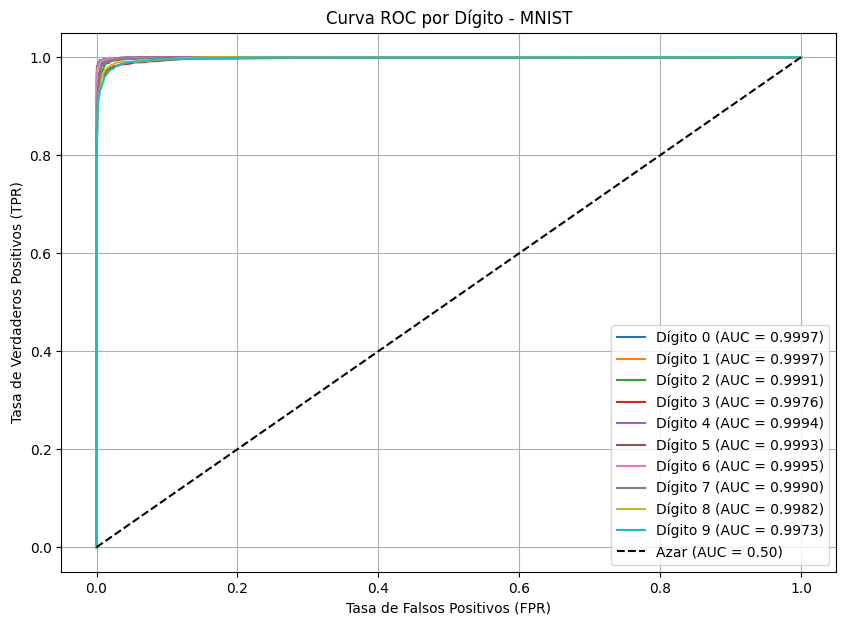

In [4]:
# Configuramos el tamaño de la figura gráfica
plt.figure(figsize=(10, 7))

# Graficamos la curva ROC para cada dígito del 0 al 9
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    plt.plot(fpr, tpr, label=f'Dígito {i} (AUC = {auc_lista[i]:.4f})')

# Graficamos la línea diagonal que representa una predicción totalmente aleatoria
plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Azar (AUC = 0.50)')

# Añadimos títulos y etiquetas a los ejes del gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC por Dígito - MNIST')
plt.legend(loc='lower right')
plt.grid(True)

# Desplegamos el gráfico en la pantalla
plt.show()

In [5]:
# Instalamos Pillow para procesar y escalar la imagen dibujada al formato 28x28
!pip install Pillow


   ¡EL MODELO HA PREDICHO EL DÍGITO: 3!   
Confianza de la predicción: 24.00%



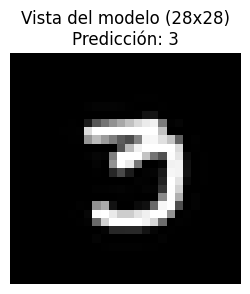


   ¡EL MODELO HA PREDICHO EL DÍGITO: 6!   
Confianza de la predicción: 30.00%



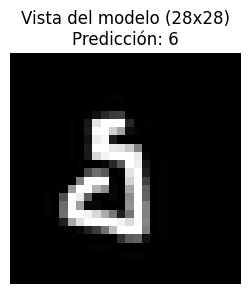

In [6]:
# Importamos herramientas de Colab e imagen
import IPython.display as display
from google.colab import output
from PIL import Image
import io
import cv2

# Código HTML5 + JavaScript para crear un canvas interactivo donde dibujar
html_canvas = """
<div style="text-align: center;">
    <h3>Dibuja un dígito (0 - 9) en el recuadro negro:</h3>
    <canvas id="canvas" width="200" height="200" style="border:2px solid #ffffff; background-color:#000000; cursor:crosshair;"></canvas><br><br>
    <button id="predict-btn" style="padding: 10px 20px; font-size: 16px; background-color: #4CAF50; color: white; border: none; borderRadius: 5px; cursor: pointer;">Predecir Dígito</button>
    <button id="clear-btn" style="padding: 10px 20px; font-size: 16px; background-color: #f44336; color: white; border: none; borderRadius: 5px; cursor: pointer;">Limpiar Lienzo</button>
</div>

<script>
    var canvas = document.getElementById('canvas');
    var ctx = canvas.getContext('2d');
    var isDrawing = false;

    // Configuración del pincel (blanco sobre fondo negro, grueso como en MNIST)
    ctx.strokeStyle = "#FFFFFF";
    ctx.lineWidth = 14;
    ctx.lineCap = "round";

    // Eventos del mouse para detectar el trazo
    canvas.addEventListener('mousedown', function(e) { isDrawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
    canvas.addEventListener('mousemove', function(e) { if (isDrawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
    canvas.addEventListener('mouseup', function() { isDrawing = false; });
    canvas.addEventListener('mouseleave', function() { isDrawing = false; });

    // Botón para limpiar el lienzo
    document.getElementById('clear-btn').addEventListener('click', function() {
        ctx.fillRect(0, 0, canvas.width, canvas.height);
        ctx.fillStyle = "#000000";
        ctx.fillRect(0, 0, canvas.width, canvas.height);
    });

    // Botón para capturar y enviar la imagen a Python
    document.getElementById('predict-btn').addEventListener('click', function() {
        var dataURL = canvas.toDataURL('image/png');
        google.colab.kernel.invokeFunction('notebook.predict', [dataURL], {});
    });
</script>
"""

# Función en Python que procesa la imagen recortada y la pasa al modelo
def procesar_y_predecir(data_url):
    # Decodificamos la imagen codificada en base64 desde JavaScript
    data = data_url.split(',')[1]
    import base64
    img_bytes = base64.b64decode(data)

    # Abrimos la imagen con PIL y la convertimos a escala de grises
    img = Image.open(io.BytesIO(img_bytes)).convert('L')

    # Redimensionamos la imagen de 200x200 a 28x28 píxeles (igual que MNIST)
    img_resized = img.resize((28, 28), Image.Resampling.LANCZOS)

    # Convertimos la imagen a un array de NumPy
    img_array = np.array(img_resized)

    # Aplanamos el array de 2D (28x28) a 1D (784 elementos)
    img_flat = img_array.reshape(1, 784)

    # Realizamos la predicción con nuestro modelo de Random Forest
    prediccion = modelo.predict(img_flat)[0]
    probabilidades = modelo.predict_proba(img_flat)[0]

    # Mostramos los resultados en la salida de Colab
    print("\n" + "="*40)
    print(f"   ¡EL MODELO HA PREDICHO EL DÍGITO: {prediccion}!   ")
    print("="*40)
    print(f"Confianza de la predicción: {probabilidades[prediccion] * 100:.2f}%\n")

    # Graficamos la imagen escalada a 28x28 para visualizar lo que vio el modelo
    plt.figure(figsize=(3, 3))
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Vista del modelo (28x28)\nPredicción: {prediccion}")
    plt.axis('off')
    plt.show()

# Registramos la función de callback para conectar JavaScript con Python
output.register_callback('notebook.predict', procesar_y_predecir)

# Desplegamos el lienzo en pantalla
display.display(display.HTML(html_canvas))